# Tasic et al. (2018) -- Shared and distinct transcriptomic cell types across neocortical areas
The original paper can be found here: https://www.nature.com/articles/s41586-018-0654-5

__Abstract__: The neocortex contains a rich variety of neuronal and non-neuronal cell types, organized into layers and specialized areas. Tasic et al. profile ~23k individual cells from adult mouse primary visual cortex (VISp) and anterior lateral motor cortex (ALM) using deep single-cell RNA-seq, and define 133 transcriptomic cell types. Inhibitory (GABAergic) neuron types are largely shared between the two regions, whereas most glutamatergic excitatory neuron types are specific to either VISp or ALM. By combining scRNA-seq with retrograde labelling of long-range projections, they link transcriptomic excitatory types to their projection targets and establish a joint transcriptomic and projectional taxonomy of neocortical cell types.

A mouse neocortical benchmark: full-length Smart-seq v4 scRNA-seq of adult C57BL/6J mouse cortex, covering neurons and glia from VISp and ALM. Cells were FACS-sorted from transgenic reporter lines and sequenced on an Illumina HiSeq 2500, yielding high-depth expression profiles (often tens of thousands of detected genes per cell). The dataset is widely used as a reference atlas for mouse cortical cell types and as a benchmark for clustering, annotation, and data-integration methods, since both broad classes (excitatory, inhibitory, non-neuronal) and fine-grained transcriptomic types are well curated.

From public resources (Allen Institute / GEO): The data are deposited under GEO series accession GSE115746 and are also available in processed form via the Allen Cell Types database. For benchmarking purposes, many studies work with a quality-filtered subset of ~20--25k cells, retaining well-annotated excitatory and inhibitory neurons (and sometimes selected non-neuronal classes) to create a reference dataset with known cell-type labels across layers and areas.
Tasic, Bosiljka, et al. "Shared and distinct transcriptomic cell types across neocortical areas." *Nature* 563.7729 (2018): 72--78.

---

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from carve import CARVE

from case_study_plotting import (
    baseline_metrics_over_k,
    build_baseline_best_labels,
    extract_ari_comparison,
    plot_ari_comparison_lollipop,
    plot_ari_comparison_bar,
    plot_ari_comparison_dotplot,
    plot_composite_figure_with_splits,
    plot_dim_red,
    plot_label_split_counts,
    fragmentation_report,
    merging_report,
    plot_label_merge_counts,
    alluvial_compare,
)

In [3]:
# --- Configuration ---
SUBSAMPLE = True
subsample_size = 0.1
RANDOM_SEED = 42
K = 40

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

def get_n_jobs():
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4
    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Dataset Overview & Motivation

In [5]:
tasic_dir = Path("../../data/TasicData/")

X_raw = pd.read_csv(tasic_dir / "tasic-post-PCA_23822x1000-final.csv")
labels = pd.read_csv(tasic_dir / "tasic-metadata-final.csv")
y_raw = labels["cluster_id"]

print(f"Cells: {X_raw.shape[0]:,}")
print(f"Features (PCA-reduced): {X_raw.shape[1]:,}")
print(f"Cell types: {y_raw.nunique()}")
print()
print("Class distribution:")
print(labels["class_label"].value_counts().to_string())

Cells: 23,822
Features (PCA-reduced): 1,000
Cell types: 133

Class distribution:
class_label
Glutamatergic    11905
GABAergic        10534
Non-Neuronal      1047
Endothelial        336


We compute a t-SNE embedding with perplexity 22 (minimizes reconstruction loss for this dataset):

In [6]:
Z = TSNE(perplexity=22, random_state=RANDOM_SEED).fit_transform(X_raw)

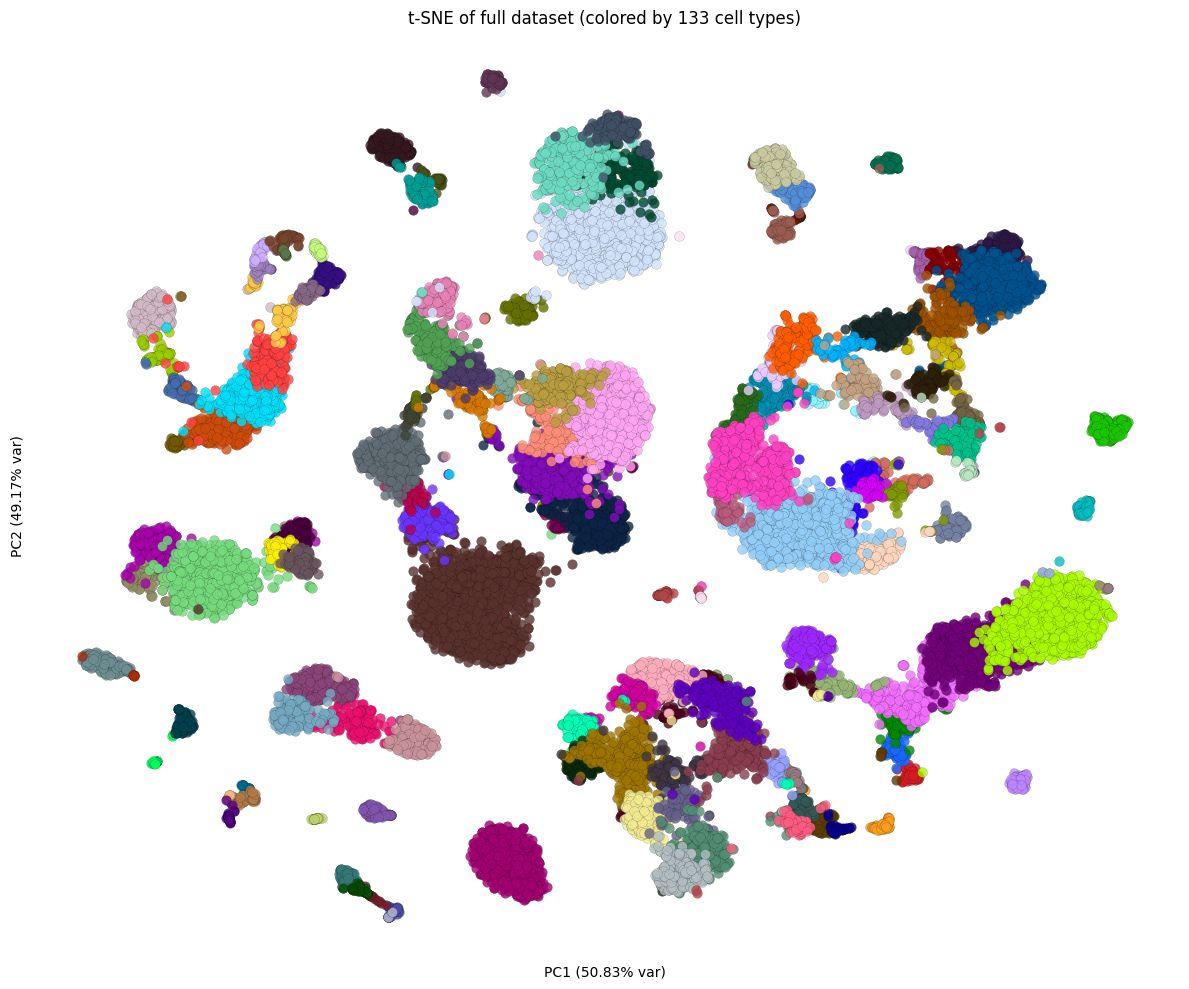

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 't-SNE of full dataset (colored by 133 cell types)'}, xlabel='PC1 (50.83% var)', ylabel='PC2 (49.17% var)'>)

In [7]:
plot_dim_red(X=Z, y=y_raw, show_legend=False, title="t-SNE of full dataset (colored by 133 cell types)")

With 133 fine-grained transcriptomic cell types, selecting the number of clusters *k* is non-trivial. Different choices of *k* produce qualitatively different partitions:

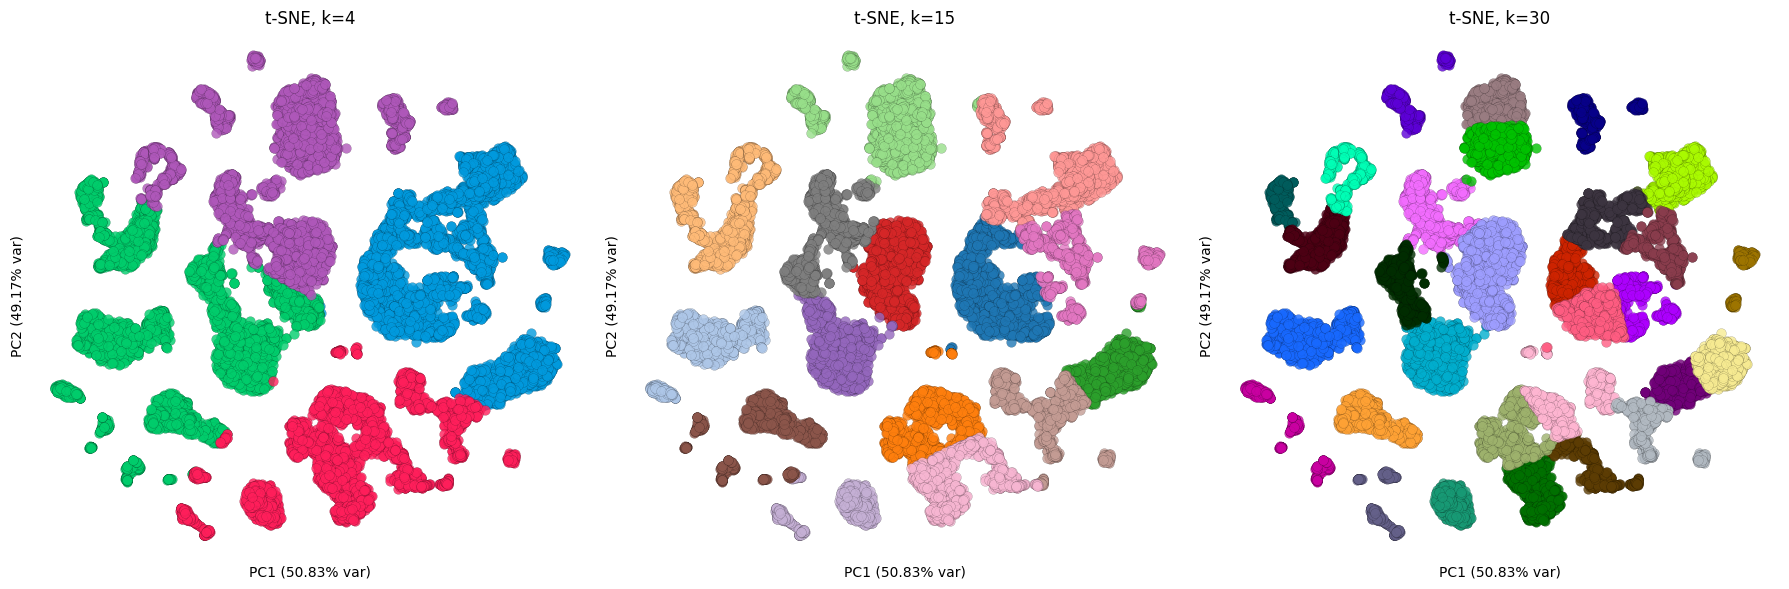

In [8]:
labels_4 = KMeans(n_clusters=4, random_state=RANDOM_SEED).fit_predict(Z)
labels_15 = KMeans(n_clusters=15, random_state=RANDOM_SEED).fit_predict(Z)
labels_30 = KMeans(n_clusters=30, random_state=RANDOM_SEED).fit_predict(Z)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_dim_red(X=Z, y=labels_4, legend_title="Cluster", ax=axes[0], show=False, show_legend=False, title="t-SNE, k=4")
plot_dim_red(X=Z, y=labels_15, legend_title="Cluster", ax=axes[1], show=False, show_legend=False, title="t-SNE, k=15")
plot_dim_red(X=Z, y=labels_30, legend_title="Cluster", ax=axes[2], show=False, show_legend=False, title="t-SNE, k=30")

plt.tight_layout()
plt.show()

---

## 2. Subsampling & Baseline Metrics

In [9]:
X = Z
y = y_raw

if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y_raw))
    selected_idx = y_raw.index[idx]

    X = X[idx]
    y = y_raw.loc[selected_idx]

    print(f"Subsampled to {X.shape[0]:,} cells ({frac:.0%})")

Subsampled to 2,382 cells (10%)


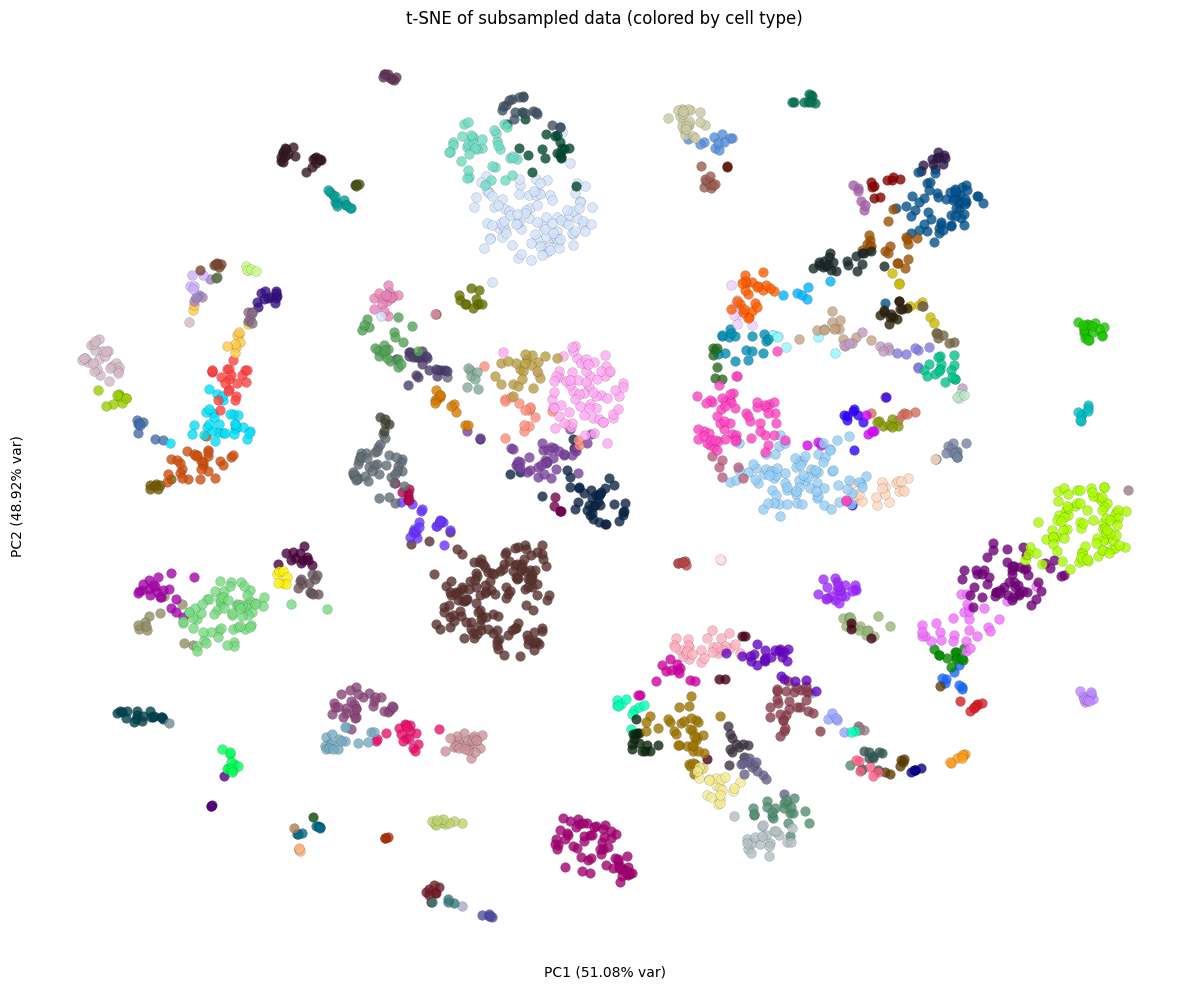

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 't-SNE of subsampled data (colored by cell type)'}, xlabel='PC1 (51.08% var)', ylabel='PC2 (48.92% var)'>)

In [10]:
plot_dim_red(X=X, y=y, show_legend=False, title="t-SNE of subsampled data (colored by cell type)")

We evaluate four classical internal validation indices across *k* = 10..40 for KMeans and Agglomerative clustering (ward and single linkage):

In [11]:
ks = list(range(10, K + 1))

model_grids = [
    (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "single"]}),
]


baseline selections (max metric):
  - Silhouette: k=38, score=0.5085, ari=0.6400   [KMeans]
  - Gap Statistic: k=35, score=2.8963, ari=0.2835   [Agglomerative (linkage=single)]
  - DB: k=25, score=0.6473, ari=0.2515   [Agglomerative (linkage=single)]
  - CH: k=40, score=4187.6274, ari=0.6481   [KMeans]


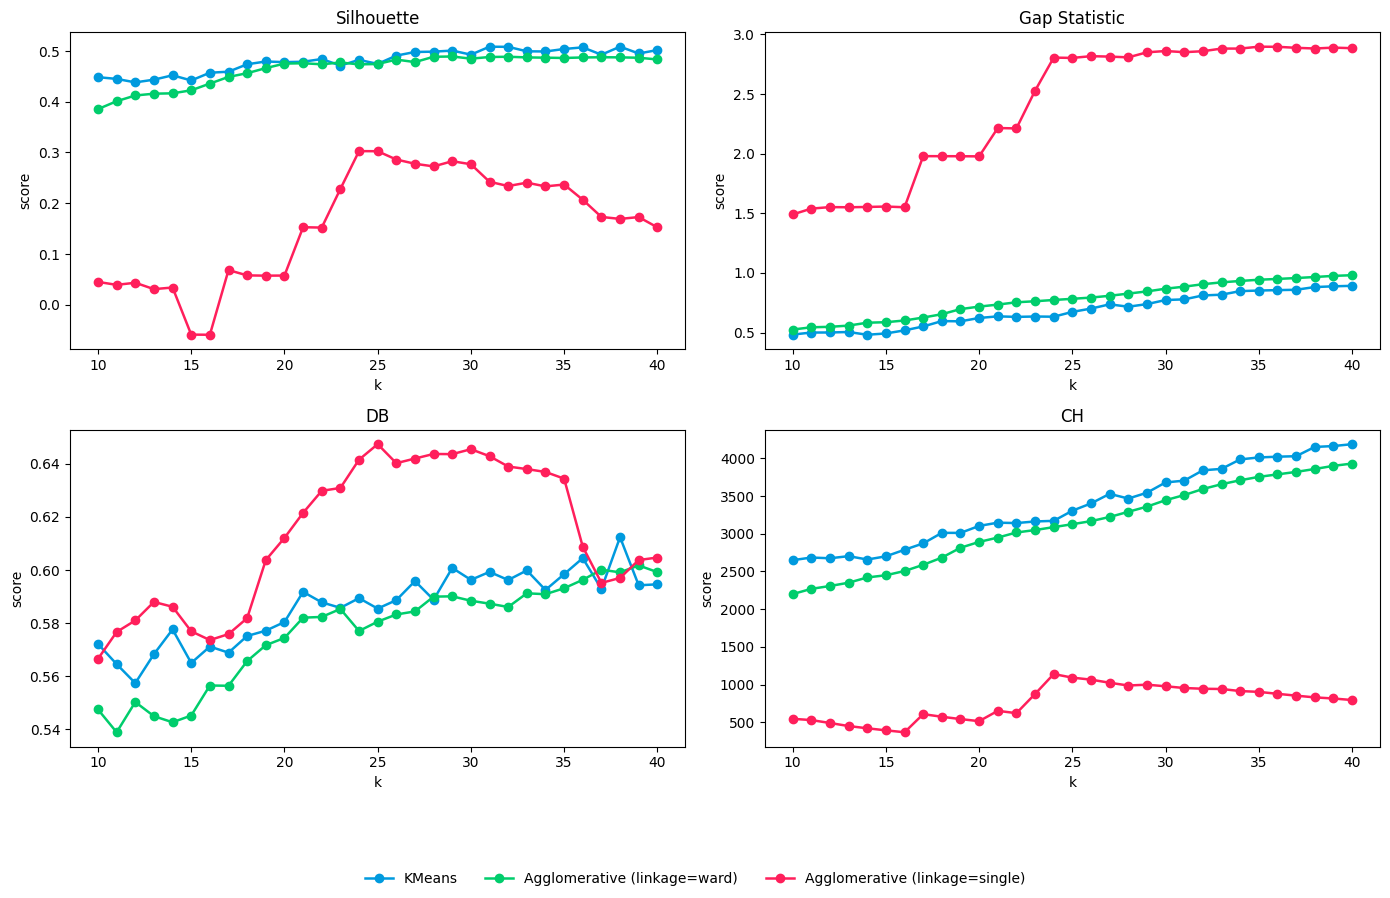

In [12]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,
    model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
    ncols=2,
    figsize=(14, 9),
)

---

## 3. CARVE Analysis

In [13]:
carve = CARVE(
    estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
)

carve.fit(X, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2382
[CARVE] n_features         : 2
[CARVE] n_clusters         : [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 93
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/93] est=KMeans n_clusters=10 | ARI_stab=0.771±0.011  ARI_gen=0.514±0.009  
[CARVE] [2/93] est=KMeans n_clusters=11 | ARI_stab=0.767±0.009  ARI_gen=0.536±0.008  
[CARVE] [3/93] est=KMeans n_clusters=12 | ARI_stab=0.759±0.009  ARI_gen=0.543±0.008  
[CARVE] [4/93] est=KMeans n_clusters=13 | ARI_stab=0.739±0.008  ARI_gen=0.527±0.009  
[CARVE] [5/93] est=KMeans n_clusters=14

,n_clusters,"array([ 2, 3..., 8, 9, 10])"
,n_resamples,100
,subsample_ratio,0.8
,estimator_param_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...veClustering'>, ...)]"
,normalization_options,None
,dim_reduction_options,None
,reference_labels,"array([ 57, 1...98, 31, 107])"
,n_jobs,10
,random_state,42
,verbose,1


<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Generalizability'>

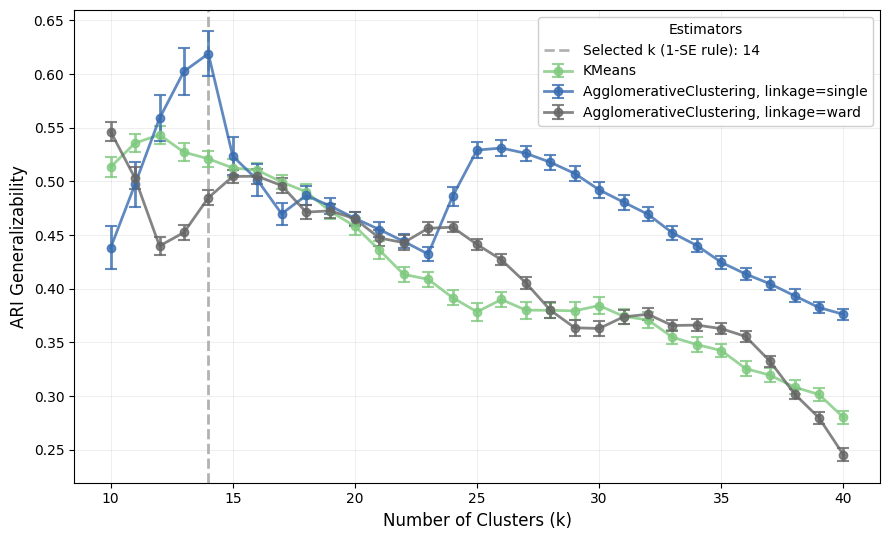

In [14]:
carve.plot_metric_over_n_clusters(measure="g", rule="1se")

<Axes: xlabel='Number of Clusters (k)', ylabel='ARI Stability'>

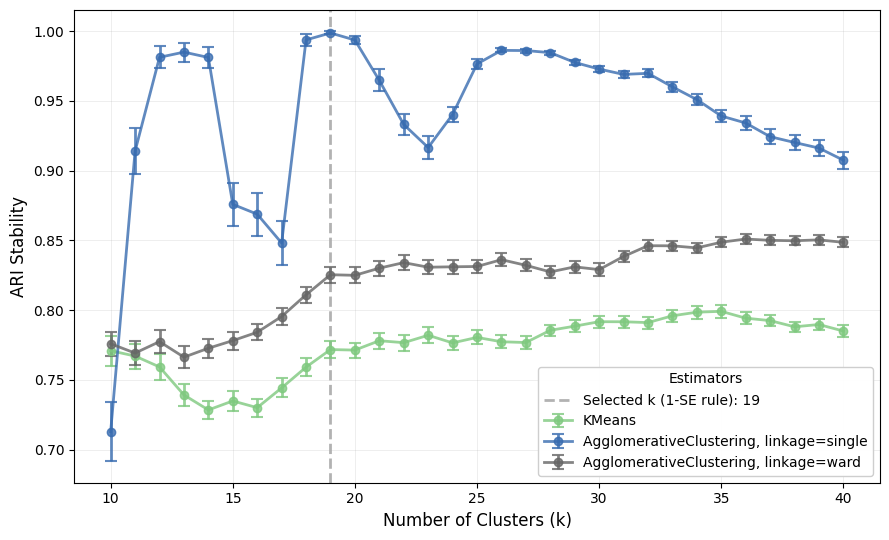

In [15]:
carve.plot_metric_over_n_clusters(measure="s", rule="1se")

<Axes: xlabel='Samples (ordered by cluster)'>

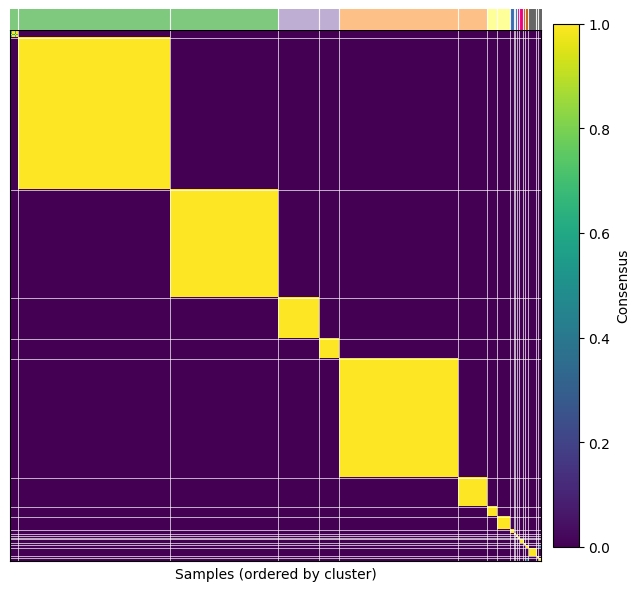

In [16]:
carve.plot_consensus_matrix(measure="s", rule="1se")

<Axes: xlabel='Cluster', ylabel='Cluster Stability (Gini)'>

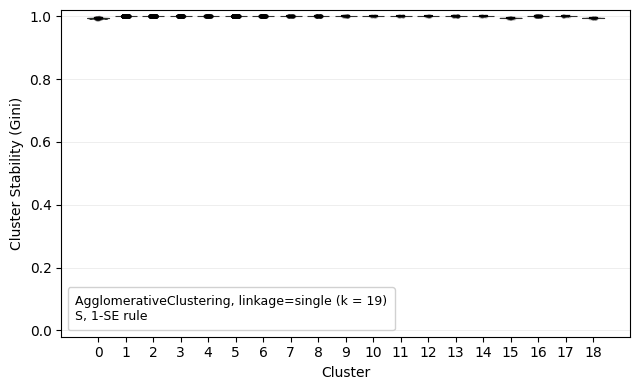

In [29]:
carve.plot_cluster_violin(measure="s", rule="1se")

---

## 4. Quantitative Comparison: CARVE vs. Baseline Metrics

### 4.1 Composite Paper Figure

In [18]:
silhouette_labels, sil_model, sil_k = build_baseline_best_labels(
    X, best_df, model_grids, metric="silhouette", random_state=RANDOM_SEED
)
print(f"Silhouette selects: {sil_model}, k={sil_k}")

Silhouette selects: KMeans, k=38


/Users/kaiwycik/GitHub/ClusteringValidation/code/notebooks/benchmarking_code/case_study_plotting.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


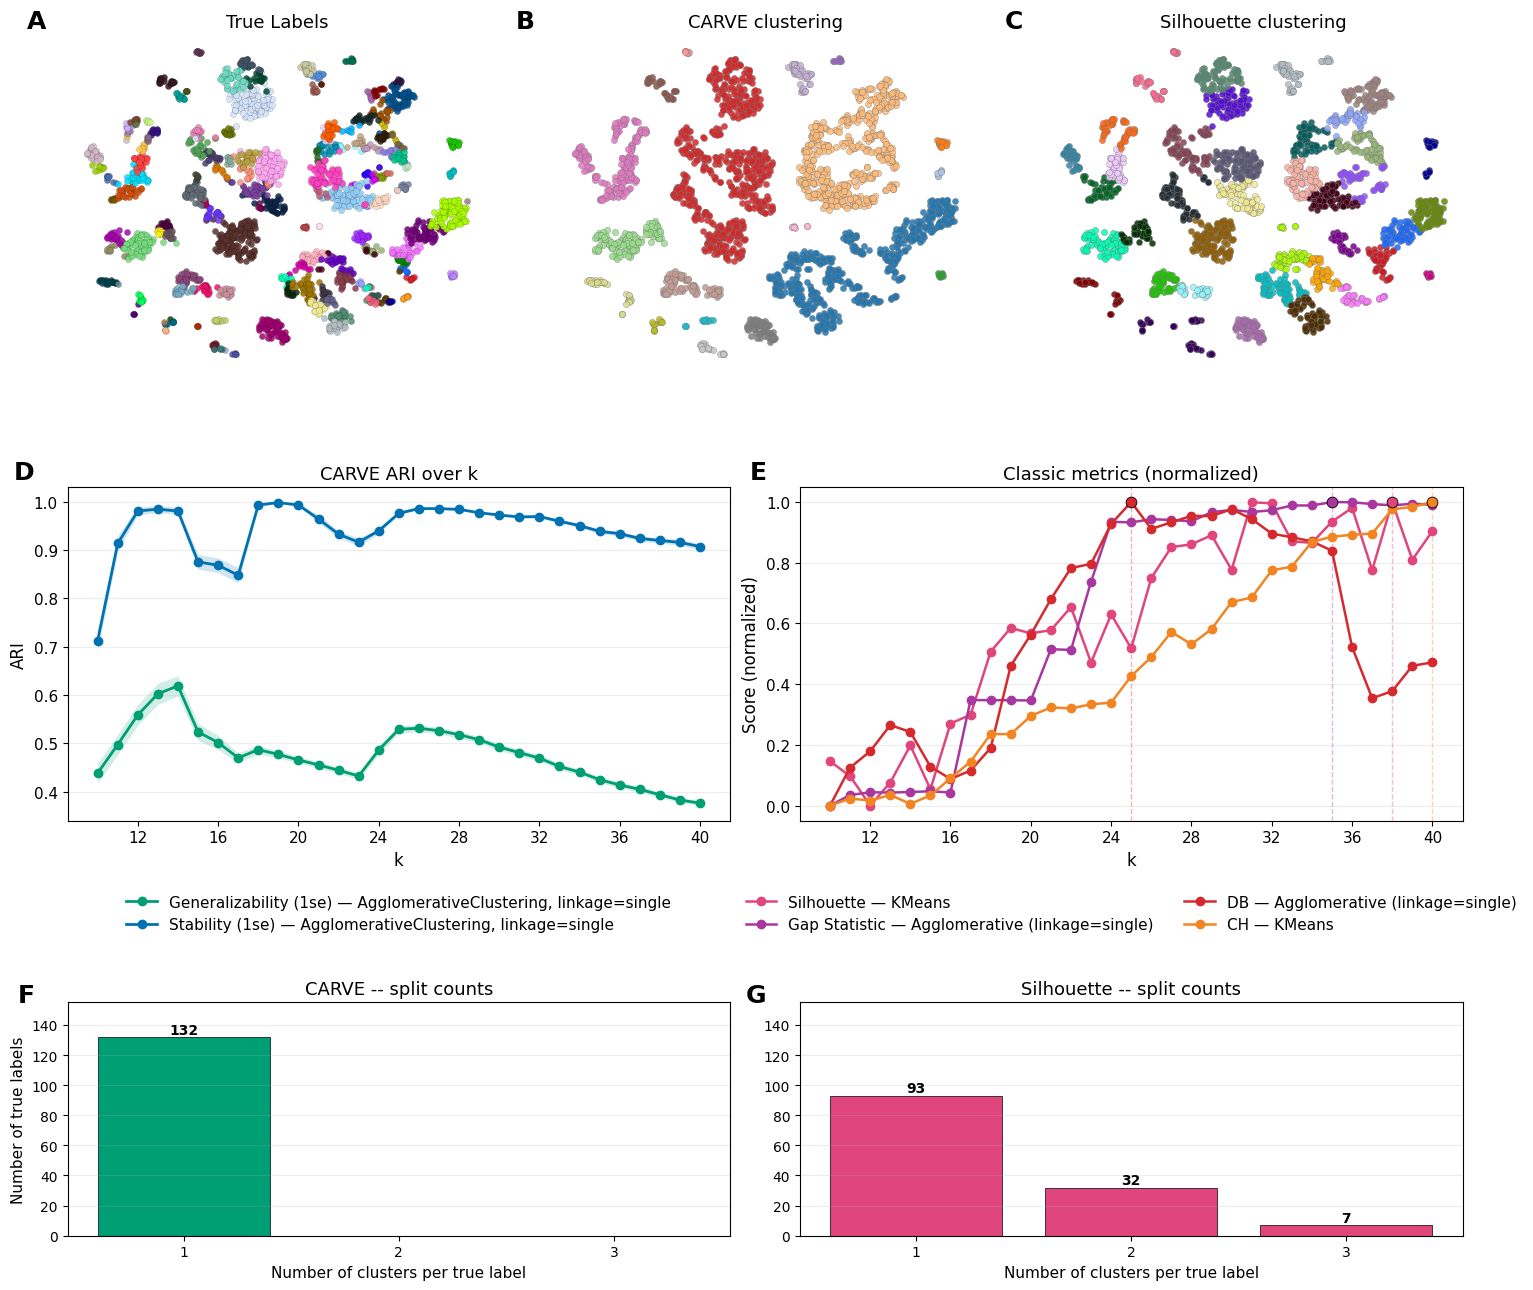

In [19]:
fig = plot_composite_figure_with_splits(
    X,
    y,
    carve,
    curves_df,
    best_df,
    silhouette_labels,
    measure="s",
    rule="1se",
    carve_measures=[("generalizability", "1se"), ("stability", "1se")],
    normalize_baseline=True,
    true_label_legend_title="Cluster ID",
    carve_title="CARVE clustering",
    baseline_title="Silhouette clustering",
    carve_line_title="CARVE ARI over k",
    baseline_line_title="Classic metrics (normalized)",
    split_title_a="CARVE -- split counts",
    split_title_b="Silhouette -- split counts",
    figsize=(18, 16),
    scatter_s=20,
    annotate_carve=False,
)

### 4.2 ARI with Ground Truth

We quantify how well each method's recommended labels agree with the 133 ground-truth cell types using the Adjusted Rand Index (ARI). For CARVE, we use the consensus labels (not a single clustering run):

In [20]:
ari_df = extract_ari_comparison(
    y_true=y,
    best_df=best_df,
    carve_obj=carve,
    X=X,
    carve_measures=[("stability", "1se"), ("generalizability", "1se")],
)
print(ari_df.to_string(index=False))

                      method                          model  k      ari   source
                  Silhouette                         KMeans 38 0.640009 baseline
               Gap Statistic Agglomerative (linkage=single) 35 0.283542 baseline
                          DB Agglomerative (linkage=single) 25 0.251496 baseline
                          CH                         KMeans 40 0.648106 baseline
       CARVE Stability (1se)                CARVE consensus 19 0.141299    carve
CARVE Generalizability (1se)                CARVE consensus 14 0.075620    carve


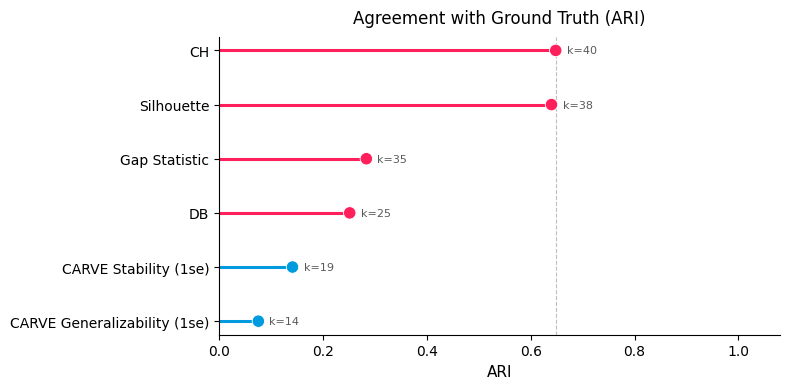

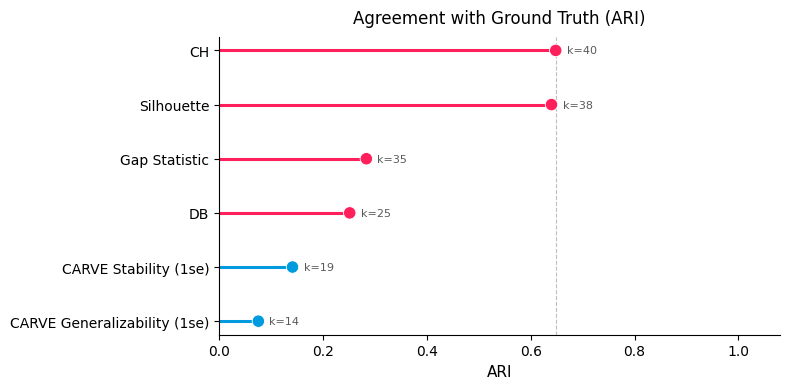

In [21]:
plot_ari_comparison_lollipop(ari_df)

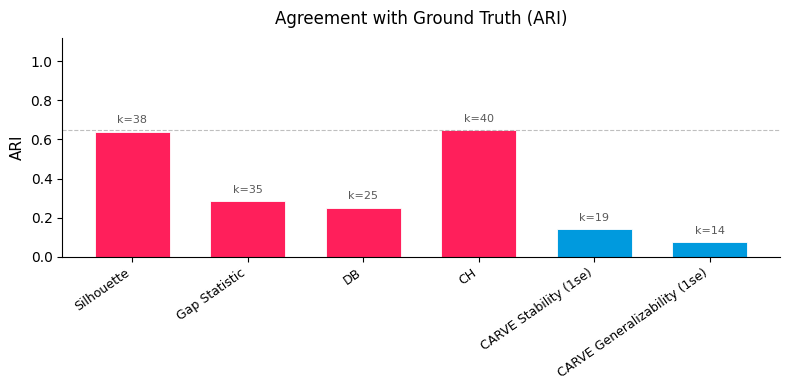

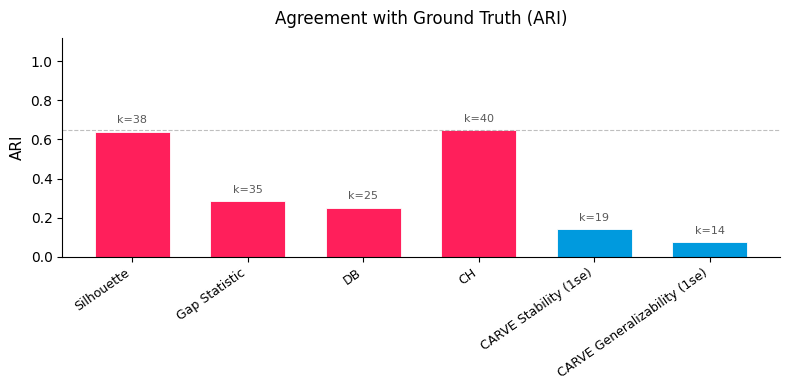

In [22]:
plot_ari_comparison_bar(ari_df)

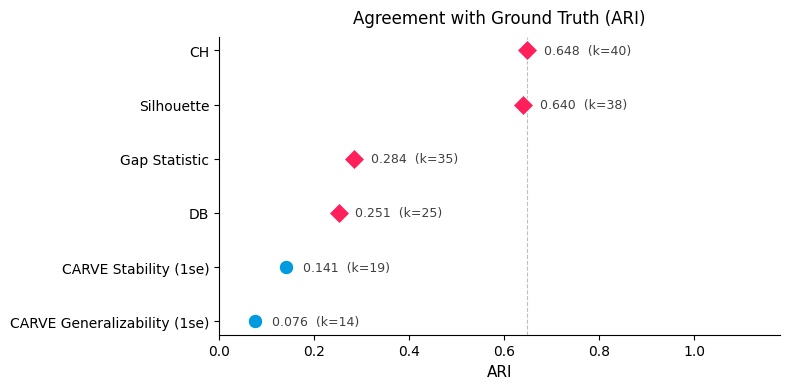

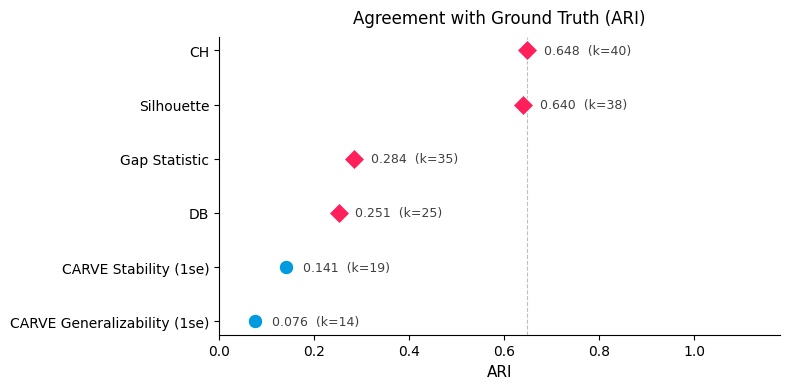

In [23]:
plot_ari_comparison_dotplot(ari_df)

### 4.3 Alluvial Diagram

In [24]:
carve_labels = carve.get_labels(measure="s", rule="1se")

fig = alluvial_compare(
    y_true=y,
    left_labels=carve_labels,
    right_labels=silhouette_labels,
    left_title="CARVE",
    right_title="Silhouette",
    true_title="True Labels",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()

### 4.4 Fragmentation & Merging Analysis

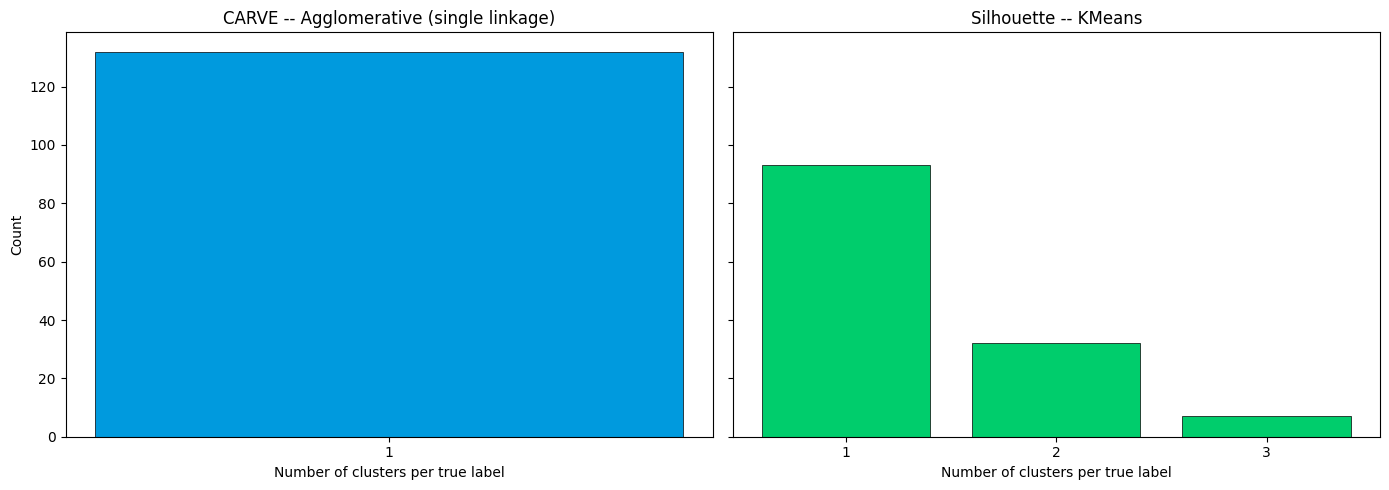

In [25]:
plot_label_split_counts(
    y.to_numpy(),
    carve_labels,
    silhouette_labels,
    title_a="CARVE -- Agglomerative (single linkage)",
    title_b="Silhouette -- KMeans",
)

In [26]:
(summ_agg, splits_agg, dist_agg, top_agg), (summ_km, splits_km, dist_km, top_km) = (
    fragmentation_report(
        y.to_numpy(),
        carve_labels,
        silhouette_labels,
        name_a="CARVE-selected agglomerative",
        name_b="silhouette-selected KMeans",
    )
)


Label fragmentation summary: CARVE-selected agglomerative
                                  Method: CARVE-selected agglomerative
                       Total true labels: 132
    Intact labels (split into 1 cluster): 132
                       Intact labels (%): 100.000
           Labels split into 2+ clusters: 0
       Labels split into 2+ clusters (%): 0.000
       Average # clusters per true label: 1.000
        Median # clusters per true label: 1.000
               25th percentile of splits: 1.000
               75th percentile of splits: 1.000
               90th percentile of splits: 1.000
               95th percentile of splits: 1.000
       Max # clusters for any true label: 1
             # labels at max split count: 132
           Labels split into 3+ clusters: 0
           Labels split into 5+ clusters: 0
           Labels split into 8+ clusters: 0

How many true labels were split into N clusters:
 clusters_per_label  n_labels
                  1       132

Most fragmented


Cluster merging summary: CARVE
                                       Method: CARVE
                     Total predicted clusters: 19
         Pure clusters (contain 1 true label): 6
                            Pure clusters (%): 31.579
              Clusters merging 2+ true labels: 13
          Clusters merging 2+ true labels (%): 68.421
            Average # true labels per cluster: 6.947
             Median # true labels per cluster: 4.000
              25th percentile of merge counts: 1.000
              75th percentile of merge counts: 5.000
              90th percentile of merge counts: 22.400
              95th percentile of merge counts: 28.100
             Max # true labels in any cluster: 29
                # clusters at max merge count: 1
              Clusters merging 3+ true labels: 11
              Clusters merging 5+ true labels: 5
              Clusters merging 8+ true labels: 4
                          Mean cluster purity: 0.615
                        Median cluster

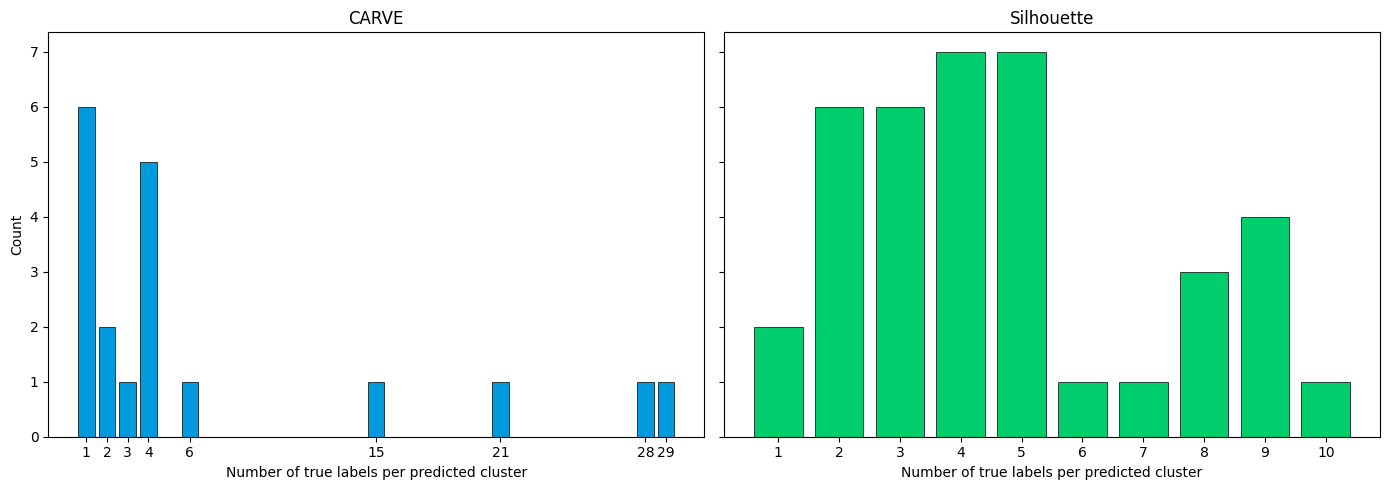

In [27]:
res_a, res_b = merging_report(
    y_true=y,
    labels_a=carve_labels,
    labels_b=silhouette_labels,
    name_a="CARVE",
    name_b="Silhouette",
)

plot_label_merge_counts(
    y, carve_labels, silhouette_labels, title_a="CARVE", title_b="Silhouette"
)

---

## 5. Summary

Tasic illustrates a clustering scenario where it is difficult to discern a single correct *k*, but where there are resolutions that are substantially better supported than others. Classical internal validation indices (Silhouette, Gap, Davies--Bouldin, Calinski--Harabasz) disagree on both the optimal *k* and the best clustering algorithm.

CARVE supports this workflow by identifying locally supported candidates, quantifying uncertainty through resampling, and enabling targeted comparisons between a small number of plausible solutions. In particular, the CARVE-selected solution preserves ground-truth cell-type labels substantially better than the Silhouette-selected alternative, as quantified by ARI with the 133 reference cell types and by the fragmentation analysis.

---